In [441]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pickle
import matplotlib.pyplot as plt
import numpy as n



df = pd.read_csv('/content/dados_clientes_padaria.csv')

df

,id_cliente,frequencia_semanal,gasto_medio_por_visita,produto_favorito,horario_visita,membro_fidelidade
0,1,7,9.63,Bolo de Cenoura,Manhã,0
1,2,4,20.05,Pão Francês,Manhã,1
2,3,5,8.40,Misto Quente,Tarde,0
3,4,7,38.90,Pão de Queijo,Manhã,1
4,5,3,17.25,Bolo de Cenoura,Manhã,0
...,...,...,...,...,...,...
1517,1518,2,9.45,Café Expresso,Manhã,0
1518,1519,6,45.03,Suco Natural,Tarde,0
1519,1520,6,5.55,Pão Francês,Manhã,0
1520,1521,3,21.65,Pão de Queijo,Manhã,1


In [442]:
df = df.drop_duplicates()


In [443]:
 df.isnull().sum()

,0
id_cliente,0
frequencia_semanal,0
gasto_medio_por_visita,0
produto_favorito,0
horario_visita,0
membro_fidelidade,0


In [444]:
df['id_cliente'].value_counts()

,count
id_cliente,
1522,1
1,1
1506,1
1505,1
1504,1
...,...
7,1
6,1
5,1


In [445]:
df['frequencia_semanal'].value_counts()

,count
frequencia_semanal,
1,234
4,221
5,220
6,220
7,214
3,208
2,205


In [446]:
df['gasto_medio_por_visita'].value_counts()

,count
gasto_medio_por_visita,
42.13,4
29.41,4
39.69,4
44.59,3
5.01,3
...,...
8.49,1
43.33,1
22.43,1


In [447]:
df['produto_favorito'].value_counts()

,count
produto_favorito,
Pão Francês,233
Croissant,230
Café Expresso,223
Bolo de Cenoura,214
Pão de Queijo,209
Suco Natural,208
Misto Quente,205


In [449]:
df['horario_visita'].value_counts()

,count
horario_visita,
Manhã,931
Tarde,456
Noite,135


In [450]:
df['membro_fidelidade'].value_counts()

,count
membro_fidelidade,
0,1071
1,451


In [451]:
df_encoded = pd.get_dummies(df, columns=['produto_favorito'], drop_first=True)
x = df_encoded[['frequencia_semanal', 'gasto_medio_por_visita'] + [col for col in df_encoded.columns if 'produto_favorito_' in col or 'horario_visita_' in col]]
y = df_encoded['membro_fidelidade']

In [452]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.15, random_state=42)

In [453]:
scaler = StandardScaler()
x_teste_original = x_teste.copy()
x_treino = scaler.fit_transform(x_treino)
x_teste = scaler.transform(x_teste)


In [454]:
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
modelo_lr.fit(x_treino, y_treino)

modelo_lr = LogisticRegression()
modelo_lr.fit(x_treino, y_treino)

LogisticRegression()

In [455]:
previsao = modelo_lr.predict(x_teste)
acuracia = accuracy_score(y_teste, previsao)
matriz = confusion_matrix(y_teste, previsao)

previsao_lr = modelo_lr.predict(x_teste)
acuracia_lr = accuracy_score(y_teste, previsao_lr)
matriz_lr = confusion_matrix(y_teste, previsao_lr)

In [456]:
print(f"Acurácia (LR): {acuracia_lr * 100:.2f}%")
print(f"Matriz de confusão (LR):\n{matriz_lr}\n")

print(f"Acurácia: {acuracia * 100:.2f}%")
print(f"Matriz de confusão:\n{matriz}\n")


Acurácia (LR): 74.67%
Matriz de confusão (LR):
[[171   0]
 [ 58   0]]

Acurácia: 74.67%
Matriz de confusão:
[[171   0]
 [ 58   0]]



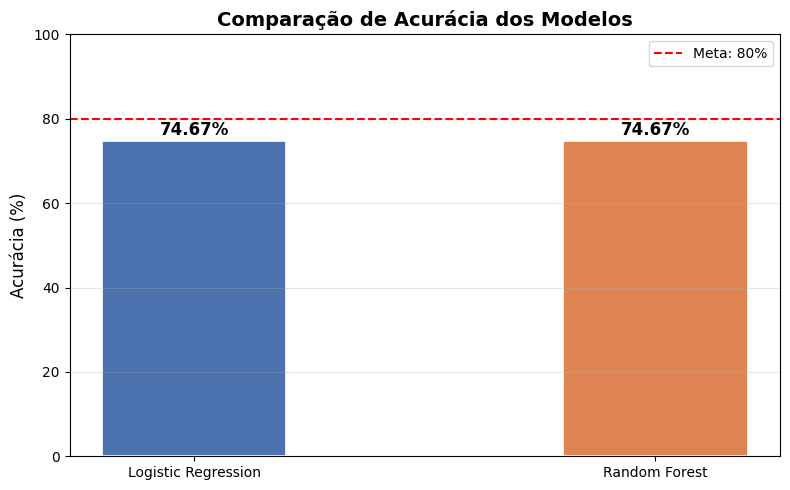

In [459]:
modelos = ['Logistic Regression', 'Random Forest']
acuracias = [74.67, 74.67]

fig, ax = plt.subplots(figsize=(8, 5))

cores = ['#4C72B0', '#DD8452']
barras = ax.bar(modelos, acuracias, color=cores, width=0.4, edgecolor='white', linewidth=1.2)

ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='Meta: 80%')

for barra, valor in zip(barras, acuracias):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.5,
            f'{valor:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_ylabel('Acurácia (%)', fontsize=12)
ax.set_title('Comparação de Acurácia dos Modelos', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('acuracia_modelos.png', dpi=150)
plt.show()

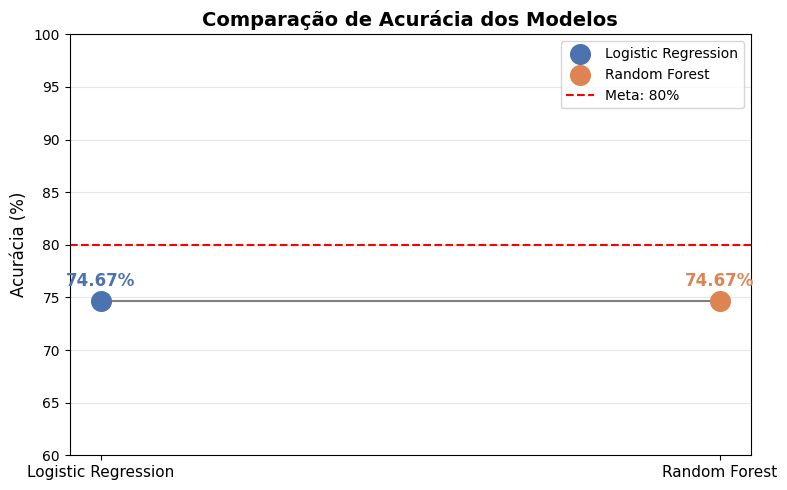

In [461]:
modelos  = ['Logistic Regression', 'Random Forest']
acuracias = [74.67, 74.67]

fig, ax = plt.subplots(figsize=(8, 5))

cores = ['#4C72B0', '#DD8452']

for i, (modelo, acuracia, cor) in enumerate(zip(modelos, acuracias, cores)):
    ax.scatter(i, acuracia, color=cor, s=200, zorder=5, label=modelo)
    ax.text(i, acuracia + 1, f'{acuracia:.2f}%', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=cor)

ax.plot(range(len(modelos)), acuracias, color='gray', linestyle='-', linewidth=1.5, zorder=4)

ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='Meta: 80%')

ax.set_xticks(range(len(modelos)))
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylim(60, 100)
ax.set_ylabel('Acurácia (%)', fontsize=12)
ax.set_title('Comparação de Acurácia dos Modelos', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('acuracia_pontos.png', dpi=150)
plt.show()

In [460]:
with open('modelo_padaria.pkl', 'wb') as f:
    pickle.dump(modelo_lr, f)

print("Modelo salvo com sucesso!")

with open('modelo_padaria.pkl', 'rb') as f:
    modelo_carregado = pickle.load(f)

previsao = modelo_carregado.predict(x_teste)
print(f"Modelo carregado! Acurácia: {accuracy_score(y_teste, previsao)*100:.2f}%")

Modelo salvo com sucesso!
Modelo carregado! Acurácia: 74.67%
